# The CME market-by-order suite, end to end

`RVUtils/MBO` replays the full CME order book — every add, cancel, modify and
trade, with the order id attached — for SR3 and the six Treasury futures roots.
The store behind this notebook holds **527 sessions** over three months:
3.08 billion top-of-book states and 24.9 million trades, built from 64 GB of
GLBX.MDP3.

This notebook is the tour. Each section asks one question a desk actually has,
and answers it from the store rather than from a settle file:

| | |
|---|---|
| 1 | What is in the store? |
| 2 | What did the book look like? |
| 3 | What does it cost to cross? |
| 4 | Where is the flow, and does it move the price? |
| 5 | What does a trade do to the price afterwards? |
| 6 | Could I have been filled? |
| 7 | How much liquidity was hidden? |
| 8 | Which instrument moves first? |
| 9 | Is any of this trustworthy? |

Everything below is computed here. Where a number appears in prose it was
printed by the cell above it.

In [1]:
from __future__ import annotations

import datetime
import sys
import warnings
from pathlib import Path

# Walk up to the repository root, so the notebook runs from wherever it is opened
# -- the kernel's working directory is this file's folder, not the repo.
REPO = Path.cwd()
while not (REPO / "RVUtils").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from RVUtils.MBO import plots
from RVUtils.MBO.analytics.flow import ofi_bars, trade_flow
from RVUtils.MBO.analytics.icebergs import (
    hidden_volume_share,
    iceberg_summary,
    km_size_distribution,
)
from RVUtils.MBO.analytics.impact import effective_spread, impact_by_size, kyle_lambda
from RVUtils.MBO.analytics.leadlag import epps_curve, hy_signature, lead_lag
from RVUtils.MBO.analytics.liquidity import quoted_spread
from RVUtils.MBO.analytics.mlofi import mlofi_bars, mlofi_regression, ofi_bar_scan
from RVUtils.MBO.archive import MboArchive
from RVUtils.MBO.book import build_price_grid, replay_book
from RVUtils.MBO.lifecycle import rank_inversions, replay_lifecycle
from RVUtils.MBO.mlofi import mlofi_session
from RVUtils.MBO.products import PRODUCTS, spec_for
from RVUtils.MBO.sim import fill_probability_curve, simulate_resting_order
from RVUtils.MBO.store.panel import panel_events
from RVUtils.MBO.store.reader import available_dates, read_catalog, read_tob, read_trades
from RVUtils.MBO.verify import implied_vs_listed, invariants

warnings.filterwarnings("ignore")
plots.theme()
pd.set_option("display.width", 200)

STORE = "D:/mbo_store"
DAY = datetime.date(2026, 7, 14)          # a Tuesday, mid-sample, present on every root
ROOTS = ("SR3", "ZT", "ZF", "ZN", "TN", "ZB", "UB")


def show(fig=None):
    plt.tight_layout()
    plt.show()

## 1. What is in the store

One parquet file per `(product, date, kind)`, one row group per symbol. The
catalogue is the index: one row per instrument-day, carrying the price grid
needed to decode a tick index, the parsed leg structure, and the replay
invariants.

In [2]:
cat = pd.concat(
    [read_catalog(STORE, p, available_dates(STORE, "tob", p)).assign(product=p)
     for p in ROOTS],
    ignore_index=True,
)

summary = cat.groupby("product").agg(
    sessions=("date", "nunique"),
    instrument_days=("symbol", "size"),
    records=("n_records", "sum"),
    tob_states=("n_tob", "sum"),
    trades=("n_trades", "sum"),
).sort_values("records", ascending=False)
summary["states_per_record"] = (summary["tob_states"] / summary["records"]).round(3)
print(summary.to_string())
print(f"\ntotal: {summary['sessions'].sum()} sessions, "
      f"{summary['records'].sum():,} records, "
      f"{summary['tob_states'].sum():,} top-of-book states")

         sessions  instrument_days     records  tob_states   trades  states_per_record
product                                                                               
SR3            53            30205  2659469186  2415335517  5076713              0.908
ZN             79              603   305470022   170610208  6341306              0.559
ZF             79              582   234871126   129830288  4282628              0.553
ZT             79              621   217327267   133905862  2253280              0.616
TN             79              550   161362381    92680860  2358275              0.574
ZB             79              485   125813666    72063838  2345910              0.573
UB             79              482   111826582    70456840  2196698              0.630

total: 527 sessions, 3,816,140,230 records, 3,084,883,413 top-of-book states


SR3 dominates the record count, and `states_per_record` says why it is also the
expensive one to store: a far larger share of its messages move the touch.

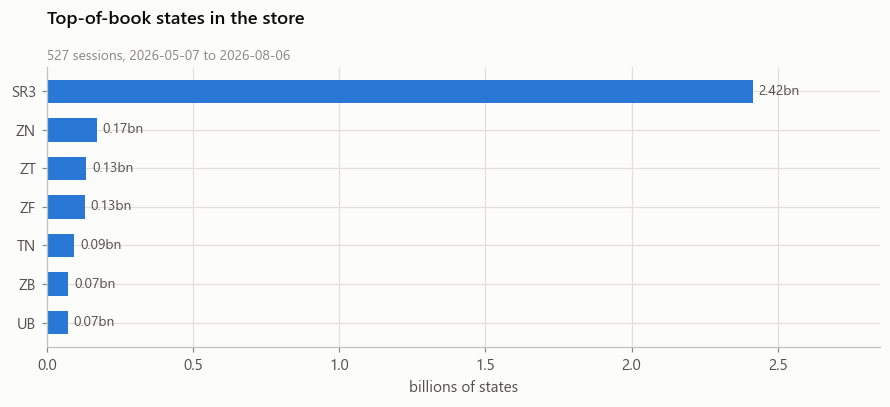

In [3]:
fig, ax = plt.subplots(figsize=(8.2, 3.8))
s = summary.sort_values("tob_states")
bars = ax.barh(s.index, s["tob_states"] / 1e9, color=plots.SERIES[0], height=0.62)
for y, v in zip(range(len(s)), s["tob_states"] / 1e9):
    ax.text(v + 0.02, y, f"{v:,.2f}bn", va="center", color=plots.INK_2, fontsize=9)
ax.set_xlim(0, (s["tob_states"] / 1e9).max() * 1.18)
plots._finish(ax, "Top-of-book states in the store",
              f"{summary['sessions'].sum()} sessions, 2026-05-07 to 2026-08-06",
              xlabel="billions of states")
show()

## 2. What did the book look like

The engine's contract, and the two places every MBO reconstruction goes wrong:
the book mutates on `A`/`C`/`M`/`R` only — `T` and `F` are trade *information* —
and the top of book is meaningful only at packet boundaries, because between the
records of one packet the book is momentarily torn.

ZNU6 on 2026-07-14: 3,873,707 touch changes, 138,685 trades
window shown: 724,389 states, 20,200 trades


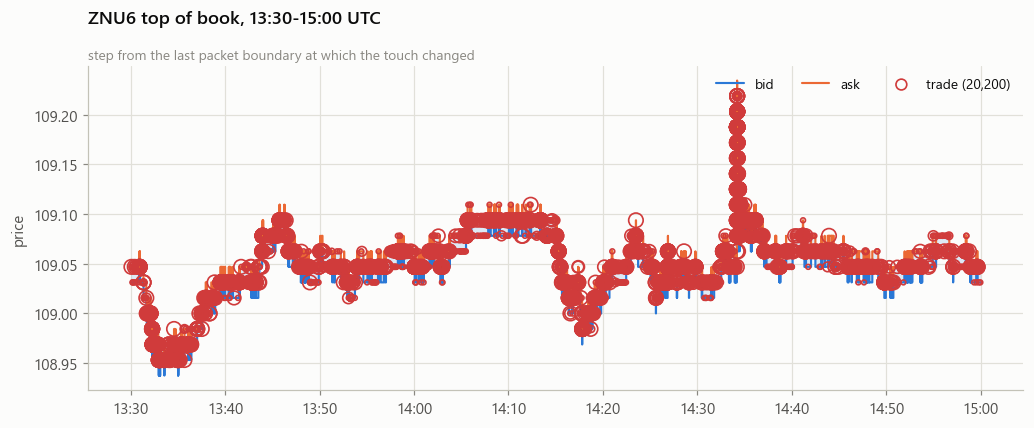

In [4]:
zn = read_tob(STORE, "ZN", [DAY], symbols=["ZNU6"])
zn_tr = read_trades(STORE, "ZN", [DAY], symbols=["ZNU6"])
rth = (pd.Timestamp(f"{DAY} 13:30", tz="UTC"), pd.Timestamp(f"{DAY} 15:00", tz="UTC"))
win = zn[(zn["ts_recv"] >= rth[0]) & (zn["ts_recv"] < rth[1])]
win_tr = zn_tr[(zn_tr["ts_recv"] >= rth[0]) & (zn_tr["ts_recv"] < rth[1])]
print(f"ZNU6 on {DAY}: {len(zn):,} touch changes, {len(zn_tr):,} trades")
print(f"window shown: {len(win):,} states, {len(win_tr):,} trades")

fig, ax = plt.subplots(figsize=(9.5, 4.0))
plots.plot_top_of_book(win, win_tr, ax=ax, title="ZNU6 top of book, 13:30-15:00 UTC")
show()

### The stub prices that made this instrument unreplayable

`ZNU6` is the busiest instrument in the archive. It could not be replayed at all
until the price ladder was banded: a handful of orders rest at prices nowhere
near the market, and a ladder spanning them needs seven million slots.

In [5]:
band = cat[(cat["symbol"] == "ZNU6")][["date", "band_lo", "band_hi", "n_slots",
                                       "n_out_of_band", "n_records"]]
print(f"ZNU6 across {len(band)} sessions:")
print(f"  ladder slots      {band['n_slots'].min():,} to {band['n_slots'].max():,}")
print(f"  orders out of band {int(band['n_out_of_band'].sum()):,} "
      f"of {int(band['n_records'].sum()):,} records")

oob = cat[cat["n_out_of_band"] > 0].groupby("product").agg(
    instrument_days=("symbol", "size"), skipped=("n_out_of_band", "sum"))
print("\nstub prices are not a ZN quirk -- every root has them:")
print(oob.to_string())
print(f"\nwhole archive: {int(cat['n_out_of_band'].sum()):,} skipped of "
      f"{int(cat['n_records'].sum()):,} records; "
      f"largest ladder ever built {int(cat['n_slots'].max()):,} slots "
      f"(the cap is 4,000,000)")

ZNU6 across 79 sessions:
  ladder slots      872 to 8,363
  orders out of band 497 of 229,691,982 records

stub prices are not a ZN quirk -- every root has them:
         instrument_days  skipped
product                          
SR3                   39     1336
TN                     3        6
UB                     3        6
ZB                    18       33
ZF                    18       77
ZN                    42      676
ZT                    21       73

whole archive: 2,207 skipped of 3,816,140,230 records; largest ladder ever built 8,857 slots (the cap is 4,000,000)


The band is a median-absolute-deviation envelope, so it is immune to any minority
of outliers however extreme. It is asserted, not assumed: an out-of-band order is
harmless only on the side that keeps it away from the touch, and the opposite
case raises. Across 527 sessions it never did.

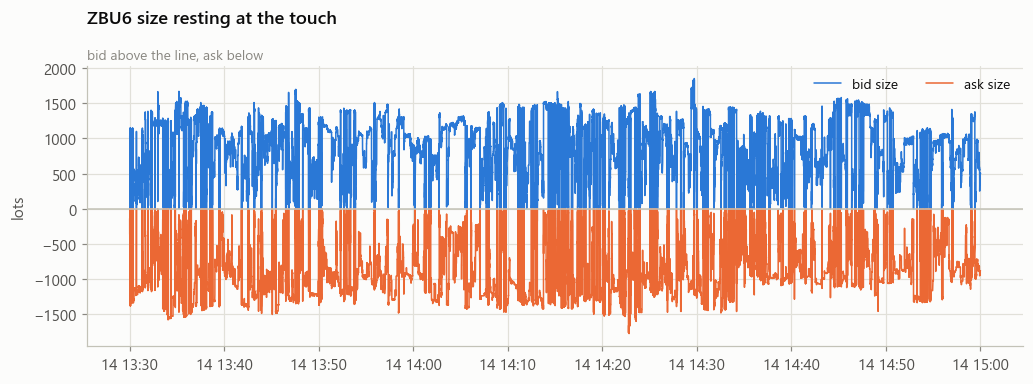

In [6]:
depth_day = read_tob(STORE, "ZB", [DAY], symbols=["ZBU6"])
d = depth_day[(depth_day["ts_recv"] >= rth[0]) & (depth_day["ts_recv"] < rth[1])]
fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(d["ts_recv"], d["bid_sz"], color=plots.SERIES[0], lw=1.0, label="bid size")
ax.plot(d["ts_recv"], -d["ask_sz"], color=plots.SERIES[1], lw=1.0, label="ask size")
ax.axhline(0, color=plots.BASELINE, lw=1.0)
ax.legend(loc="upper right", ncols=2)
plots._finish(ax, "ZBU6 size resting at the touch",
              "bid above the line, ask below", ylabel="lots")
show()

## 3. What it costs to cross

The quoted spread is time-weighted, not event-weighted: an event-weighted average
over-counts the states that flicker and under-counts the wide state that stood for
ten minutes. `two_sided_frac` is the coverage of that weighting, and locked and
crossed states are excluded from the spread and reported separately — they are
real states, but they are not quoted markets, and averaging over them produces a
width the tick lattice cannot quote.

In [7]:
rows = []
for p in ROOTS:
    # One session for SR3, whose busiest outright alone runs to tens of millions
    # of states; two for the Treasury roots, which are an order lighter.
    d0 = available_dates(STORE, "tob", p)[: (1 if p == "SR3" else 2)]
    c = read_catalog(STORE, p, d0)
    sym = c.groupby("symbol")["n_records"].sum().idxmax()
    tob = read_tob(STORE, p, d0, symbols=[sym])
    tr = read_trades(STORE, p, d0, symbols=[sym])
    tick = float(spec_for(p).outright_tick)
    q = quoted_spread(tob, tick=tick)
    eff = effective_spread(tr, tob) if len(tr) else pd.DataFrame()
    rows.append({
        "product": p, "symbol": sym, "sessions": len(d0),
        "quoted_ticks": round(q["spread_ticks"], 3),
        "effective_ticks": (round(float(eff["eff"].median()) / tick, 3)
                            if len(eff) and "eff" in eff else np.nan),
        "two_sided": round(q["two_sided_frac"], 4),
        "locked": round(q["locked_frac"], 5),
        "crossed": round(q["crossed_frac"], 6),
        "touch_lots": round(q["bid_sz_at_touch"], 0),
        "trades": len(tr),
    })
    del tob, tr, eff
cost = pd.DataFrame(rows)
print(cost.to_string(index=False))

product symbol  sessions  quoted_ticks  effective_ticks  two_sided  locked  crossed  touch_lots  trades
    SR3  SR3Z6         1         1.001              1.0     0.9167 0.00000 0.083344       897.0     394
     ZT   ZTM6         2         1.004              1.0     0.9981 0.00000 0.001852      3037.0   53387
     ZF   ZFM6         2         1.002              1.0     0.9964 0.00286 0.000747      1465.0  136540
     ZN   ZNM6         2         1.000              1.0     0.9944 0.00000 0.005554      2332.0  176043
     TN   TNM6         2         1.020              1.0     0.9965 0.00000 0.003482       911.0   65816
     ZB   ZBM6         2         1.001              1.0     0.9944 0.00000 0.005554       772.0   74099
     UB   UBM6         2         1.008              1.0     0.9944 0.00544 0.000117       526.0   77448


Every front contract quotes essentially **one tick**, and the median effective
spread equals it — taking liquidity costs exactly the touch, no more. The depth
behind that one tick is what differs, by a factor of five across the complex.

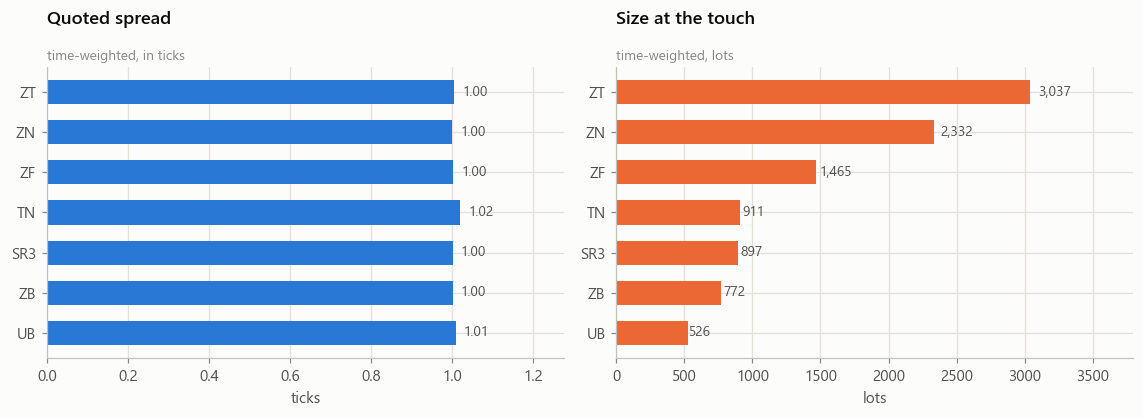

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
c = cost.sort_values("touch_lots")
axes[0].barh(c["product"], c["quoted_ticks"], color=plots.SERIES[0], height=0.6)
for y, v in enumerate(c["quoted_ticks"]):
    axes[0].text(v + 0.02, y, f"{v:.2f}", va="center", color=plots.INK_2, fontsize=9)
axes[0].set_xlim(0, max(c["quoted_ticks"]) * 1.25)
plots._finish(axes[0], "Quoted spread", "time-weighted, in ticks", xlabel="ticks")

axes[1].barh(c["product"], c["touch_lots"], color=plots.SERIES[1], height=0.6)
for y, v in enumerate(c["touch_lots"]):
    axes[1].text(v * 1.02, y, f"{v:,.0f}", va="center", color=plots.INK_2, fontsize=9)
axes[1].set_xlim(0, c["touch_lots"].max() * 1.25)
plots._finish(axes[1], "Size at the touch", "time-weighted, lots", xlabel="lots")
show()

### The listed structure is not the sum of its legs

The exchange lists calendars and butterflies as instruments in their own right,
with their own bid and ask. The question the settle file cannot answer is whether
crossing that listed book is cheaper than legging the structure out of its
outrights.

In [9]:
sr3_days = available_dates(STORE, "tob", "SR3")[:1]
sr3_cat = read_catalog(STORE, "SR3", sr3_days)
structures = (sr3_cat[(sr3_cat["kind"] == "BUTTERFLY") & (sr3_cat["n_tob"] > 5000)]
              .sort_values("n_tob", ascending=False).head(6))
print(f"listed SR3 butterflies quoting on {sr3_days[0]}: {len(structures)} shown")
print(structures[["symbol", "label", "n_tob", "n_trades", "trade_volume"]].to_string(index=False))

fly_rows = []
for _, s in structures.iterrows():
    t = read_tob(STORE, "SR3", sr3_days, symbols=[s["symbol"]])
    if t.empty:
        continue
    q = quoted_spread(t, tick=0.5)         # SR3 differentials quote in half a bp
    fly_rows.append({"symbol": s["symbol"], "tenor": s["label"],
                     "listed_bp": round(q["spread_mean"], 3),
                     "listed_ticks": round(q["spread_ticks"], 2),
                     "one_tick_share": round(q["frac_time_one_tick"], 3),
                     "touch_lots": round(q["bid_sz_at_touch"], 0)})
    del t
flies = pd.DataFrame(fly_rows)
flies["legged_bp"] = 2.0                    # four contracts at half a bp each
flies["ratio"] = (flies["listed_bp"] / flies["legged_bp"]).round(3)
print()
print(flies.to_string(index=False))

listed SR3 butterflies quoting on 2026-06-07: 5 shown
         symbol  label  n_tob  n_trades  trade_volume
SR3:BF H7-M7-U7 3m fly  10650        10          1154
SR3:BF U7-Z7-H8 3m fly   6441        43           735
SR3:BF Z6-H7-M7 3m fly   5815        25           960
SR3:BF Z7-H8-M8 3m fly   5321        52           835
SR3:BF U6-Z6-H7 3m fly   5074        33           408



         symbol  tenor  listed_bp  listed_ticks  one_tick_share  touch_lots  legged_bp  ratio
SR3:BF H7-M7-U7 3m fly      0.500          1.00           1.000       683.0        2.0  0.250
SR3:BF U7-Z7-H8 3m fly      0.929          1.86           0.141      1263.0        2.0  0.464
SR3:BF Z6-H7-M7 3m fly      0.891          1.78           0.217       314.0        2.0  0.446
SR3:BF Z7-H8-M8 3m fly      0.503          1.01           0.994      1177.0        2.0  0.252
SR3:BF U6-Z6-H7 3m fly      0.912          1.82           0.177       384.0        2.0  0.456


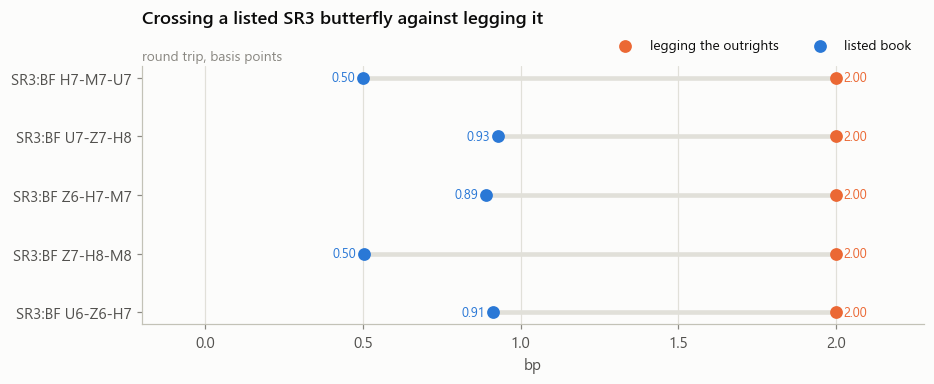

In [10]:
fig, ax = plt.subplots(figsize=(8.6, 3.6))
plots.plot_paired_dots(flies, "symbol", "listed_bp", "legged_bp",
                       "listed book", "legging the outrights",
                       "Crossing a listed SR3 butterfly against legging it",
                       subtitle="round trip, basis points", xlabel="bp", ax=ax)
show()

## 4. Where the flow is

Order-flow imbalance is the Cont-Kukanov-Stoikov measure, reproduced from the
paper rather than re-derived. Its indicators fire on **equality**, so an unchanged
price with a changed size contributes exactly the size difference — writing strict
inequalities instead reads as the obvious "improved, worsened, otherwise nothing"
and silently deletes every queue build and pull at a standing price, which on a
tick-bound contract is most of what happens.

The natural check is whether it explains the same-bar mid change.

In [11]:
scan_rows = []
for p in ("ZT", "ZF", "ZN", "ZB", "TN", "UB"):
    d0 = available_dates(STORE, "tob", p)[:2]
    c = read_catalog(STORE, p, d0)
    sym = c.groupby("symbol")["n_records"].sum().idxmax()
    tob = read_tob(STORE, p, d0, symbols=[sym])
    sc = ofi_bar_scan(tob, freqs=("1s", "10s", "60s", "300s"))
    sc["product"] = p
    scan_rows.append(sc)
    del tob
scan = pd.concat(scan_rows, ignore_index=True)
print(scan.pivot(index="product", columns="freq", values="corr")
      [["1s", "10s", "60s", "300s"]].round(3).to_string())

freq        1s    10s    60s   300s
product                            
TN       0.456  0.646  0.843  0.928
UB       0.448  0.616  0.803  0.874
ZB       0.524  0.654  0.820  0.912
ZF       0.445  0.617  0.780  0.892
ZN       0.504  0.603  0.704  0.763
ZT      -0.113  0.115  0.462  0.649


Five roots behave alike. **ZT does not** — its touch flow is uninformative at one
second and only becomes useful over minutes.

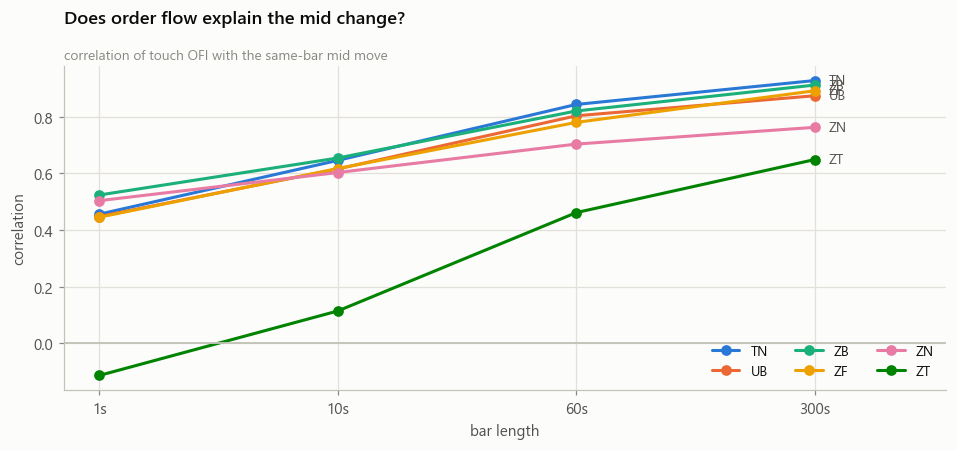

In [12]:
fig, ax = plt.subplots(figsize=(8.8, 4.2))
order = ["1s", "10s", "60s", "300s"]
xs = np.arange(len(order))
for i, (p, g) in enumerate(scan.groupby("product")):
    g = g.set_index("freq").reindex(order)
    ax.plot(xs, g["corr"], marker="o", ms=6, color=plots.series_color(i), label=p)
    ax.text(xs[-1] + 0.06, g["corr"].iloc[-1], p, color=plots.INK_2,
            fontsize=9, va="center")
ax.axhline(0, color=plots.BASELINE, lw=1.2)
ax.set_xticks(xs, order)
ax.set_xlim(-0.15, len(order) - 0.45)
ax.legend(loc="lower right", ncols=3)
plots._finish(ax, "Does order flow explain the mid change?",
              "correlation of touch OFI with the same-bar mid move",
              ylabel="correlation", xlabel="bar length")
show()

### ZT's information is deeper in the book

ZT has the finest tick of the complex and the deepest touch, so its front queue
turns over enormously without the price moving. Multi-level OFI keeps the
per-level contributions as a vector instead of summing them; the components are
collinear by construction — one arrival that changes the best bid shifts every
deeper level down a rank — so the regression needs Ridge, with the design
standardised before penalising.

In [13]:
ml_rows = []
for product, sym in (("ZT", "ZTU6"), ("ZN", "ZNU6"), ("ZB", "ZBU6")):
    r = mlofi_session(product, DAY, sym, levels=10)
    tick = float(spec_for(product).outright_tick)
    bars = mlofi_bars(r.frame, freq="1s")
    one = mlofi_regression(bars, levels=1, tick=tick)
    ten = mlofi_regression(bars, levels=10, tick=tick)
    del bars
    ml_rows.append({"product": product, "symbol": sym, "book_states": len(r.frame),
                    "r2_touch": round(one["r2_ridge"], 3),
                    "r2_ten_levels": round(ten["r2_ridge"], 3),
                    "rmse_improvement": round(ten["improvement"], 3),
                    "ridge_beats_ols": round(1 - ten["rmse_ridge"] / ten["rmse_ols"], 4),
                    "lambda": f"{ten['lambda']:.3g}",
                    "lambda_at_bound": ten["lambda_at_bound"]})
    del r
mlofi_tab = pd.DataFrame(ml_rows)
print(mlofi_tab.to_string(index=False))

product symbol  book_states  r2_touch  r2_ten_levels  rmse_improvement  ridge_beats_ols   lambda  lambda_at_bound
     ZT   ZTU6      3423394     0.004          0.549             0.318           0.0425  1.6e+04            False
     ZN   ZNU6      5262880     0.193          0.615             0.294           0.0312 1.04e+03            False
     ZB   ZBU6      2110413     0.178          0.810             0.477           0.0268      602            False


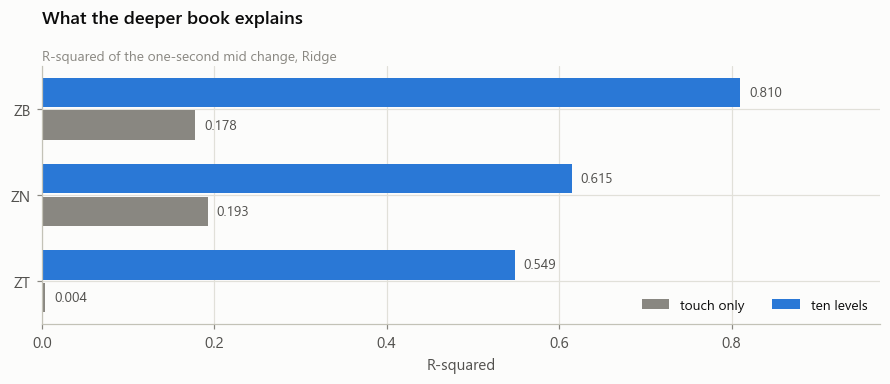

In [14]:
fig, ax = plt.subplots(figsize=(8.2, 3.6))
m = mlofi_tab.set_index("product")
y = np.arange(len(m))
ax.barh(y - 0.19, m["r2_touch"], height=0.34, color=plots.MUTED, label="touch only")
ax.barh(y + 0.19, m["r2_ten_levels"], height=0.34, color=plots.SERIES[0],
        label="ten levels")
for i, (a, b) in enumerate(zip(m["r2_touch"], m["r2_ten_levels"])):
    ax.text(a + 0.01, i - 0.19, f"{a:.3f}", va="center", fontsize=9, color=plots.INK_2)
    ax.text(b + 0.01, i + 0.19, f"{b:.3f}", va="center", fontsize=9, color=plots.INK_2)
ax.set_yticks(y, m.index)
ax.set_xlim(0, max(m["r2_ten_levels"]) * 1.2)
ax.legend(loc="lower right", ncols=2)
plots._finish(ax, "What the deeper book explains",
              "R-squared of the one-second mid change, Ridge", xlabel="R-squared")
show()

## 5. What a trade does to the price

Effective spread is what the taker paid against the mid that prevailed **strictly
before the trade's own packet** — which the store carries on the trade row, so
there is no join to get wrong. Realised spread is the same quantity measured
against the mid some horizon later; the difference between them is price impact.

In [15]:
imp_tr = read_trades(STORE, "ZN", [DAY], symbols=["ZNU6"])
imp_tob = read_tob(STORE, "ZN", [DAY], symbols=["ZNU6"])
tick_zn = float(spec_for("ZN").outright_tick)
eff = effective_spread(imp_tr, imp_tob, horizons_s=(0.1, 1.0, 10.0, 60.0, 300.0))
horizons = [0.1, 1.0, 10.0, 60.0, 300.0]
decay = pd.DataFrame({
    "horizon_s": horizons,
    "effective_ticks": [float(eff["eff"].median()) / tick_zn] * len(horizons),
    "realised_ticks": [float(eff[f"real_{h:g}s"].median()) / tick_zn for h in horizons],
    "impact_ticks": [float(eff[f"impact_{h:g}s"].median()) / tick_zn for h in horizons],
})
print(f"ZNU6, {len(eff):,} trades")
print(decay.round(4).to_string(index=False))

sized = impact_by_size(imp_tr, imp_tob, horizon_s=10.0, bins=(1, 2, 5, 10, 25, 100))
print()
print(sized.to_string(index=False))
kyle = kyle_lambda(imp_tob, imp_tr, freq="60s")
print(f"\nKyle lambda: {kyle['lam']:.3g} per lot, t={kyle['t_stat']:.1f}, "
      f"R2={kyle['r2']:.3f} over {kyle['n_bars']} bars")

ZNU6, 138,685 trades
 horizon_s  effective_ticks  realised_ticks  impact_ticks
       0.1              1.0             1.0           0.0
       1.0              1.0             1.0           0.0
      10.0              1.0             1.0           0.0
      60.0              1.0             1.0           0.0
     300.0              1.0             1.0           0.0



 size_lo  size_hi     n  volume  eff_median  real_median  impact_median
     1.0      2.0 86400   86400    0.015625     0.015625        0.00000
     2.0      5.0 14537   39312    0.015625     0.015625        0.00000
     5.0     10.0 10626   72980    0.015625     0.015625        0.00000
    10.0     25.0 12495  186091    0.015625     0.015625        0.00000
    25.0    100.0  9276  444798    0.015625     0.015625        0.00000
   100.0      inf  5351 1607000    0.015625    -0.015625        0.03125



Kyle lambda: 9.97e-06 per lot, t=26.1, R2=0.330 over 1385 bars


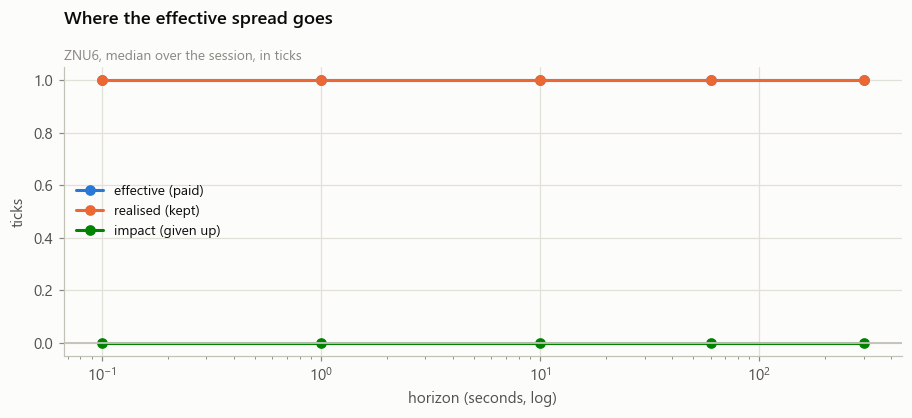

In [16]:
fig, ax = plt.subplots(figsize=(8.4, 3.9))
ax.plot(decay["horizon_s"], decay["effective_ticks"], marker="o", ms=6,
        color=plots.SERIES[0], label="effective (paid)")
ax.plot(decay["horizon_s"], decay["realised_ticks"], marker="o", ms=6,
        color=plots.SERIES[1], label="realised (kept)")
ax.plot(decay["horizon_s"], decay["impact_ticks"], marker="o", ms=6,
        color=plots.SERIES[5], label="impact (given up)")
ax.set_xscale("log")
ax.axhline(0, color=plots.BASELINE, lw=1.2)
ax.legend(loc="center left")
plots._finish(ax, "Where the effective spread goes",
              "ZNU6, median over the session, in ticks",
              ylabel="ticks", xlabel="horizon (seconds, log)")
show()

## 6. Could I have been filled

This is the question a quoted spread cannot answer. The order-lifecycle kernel
emits one row per order — where in the queue it joined, how long it rested,
whether it filled or was pulled.

CME's `MDOrderPriority` is deliberately omitted from Databento's normalized MBO,
so queue rank has to be **reconstructed** under the venue's FIFO modify rules: a
price change or a size increase forfeits position, a size decrease keeps it. That
reconstruction is an inference, so it is tested against the data itself — orders
resting at one side and price should fill in the order they joined.

In [17]:
with MboArchive().open_session("ZB", DAY, keep=True) as path:
    import databento as db
    store_ = db.DBNStore.from_file(path)
    s2i = {s: int(e["symbol"]) for s, ents in store_.metadata.mappings.items()
           for e in ents if e["symbol"]}
    rec_zb = np.concatenate([a[a["instrument_id"] == s2i["ZBU6"]]
                             for a in store_.to_ndarray(count=2_000_000)])

life = replay_lifecycle(rec_zb)
orders = life.orders
inv = rank_inversions(orders)
pairs = int(inv["n_pairs"].sum())
invs = int(inv["n_inversions"].sum())
print(f"ZBU6 on {DAY}: {life.n_orders:,} orders, "
      f"{int(orders['filled'].sum()):,} filled")
print(f"priority losses -- price moves {life.n_priority_loss_price:,}, "
      f"size increases {life.n_priority_loss_size:,}")
print(f"orphan fills (a fill with no resting order): {life.n_orphan_fills}")
print(f"\nfalsification test: {invs:,} rank inversions over {pairs:,} ordered pairs "
      f"= {invs / max(1, pairs):.5%}")
print(f"cancel-to-trade: "
      f"{(orders['exit_reason'] == 'CANCELLED').sum() / max(1, orders['filled'].sum()):.1f}")

curve = fill_probability_curve(orders)
print()
print(curve.to_string(index=False))

ZBU6 on 2026-07-14: 963,936 orders, 112,182 filled
priority losses -- price moves 261,351, size increases 59,737
orphan fills (a fill with no resting order): 1

falsification test: 44,500 rank inversions over 146,188,979 ordered pairs = 0.03044%
cancel-to-trade: 7.4

 ahead_lo  ahead_hi      n  n_filled  fill_rate  median_rest_s  median_fill_s
        0        10  37149     22177   0.596974       0.018189       0.022577
       10        50  74646     25388   0.340112       0.053906       0.269530
       50       100  78286     15692   0.200445       0.106935       1.087672
      100       500 308724     32190   0.104268       0.417734       7.059873
      500      1000 227442     10548   0.046377       1.420292      46.162919
     1000      5000 237689      6187   0.026030       1.625207      89.059251


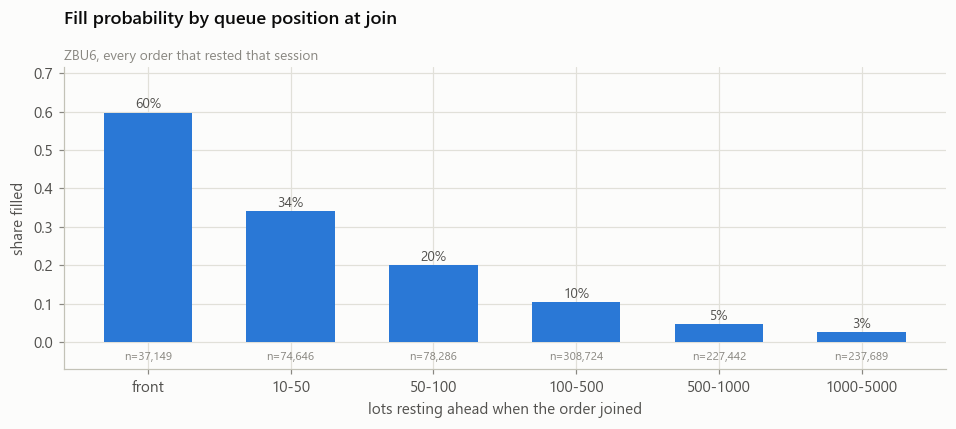

In [18]:
fig, ax = plt.subplots(figsize=(8.8, 4.0))
lab = [f"{int(lo)}-{int(hi)}" if np.isfinite(hi) else f"{int(lo)}+"
       for lo, hi in zip(curve["ahead_lo"], curve["ahead_hi"])]
lab[0] = "front"
ax.bar(range(len(curve)), curve["fill_rate"], color=plots.SERIES[0], width=0.62)
for i, (v, n) in enumerate(zip(curve["fill_rate"], curve["n"])):
    ax.text(i, v + 0.012, f"{v:.0%}", ha="center", color=plots.INK_2, fontsize=9)
    ax.text(i, -0.045, f"n={n:,}", ha="center", color=plots.MUTED, fontsize=7.5)
ax.set_xticks(range(len(curve)), lab)
ax.set_ylim(-0.07, max(curve["fill_rate"]) * 1.2)
plots._finish(ax, "Fill probability by queue position at join",
              "ZBU6, every order that rested that session",
              ylabel="share filled", xlabel="lots resting ahead when the order joined")
show()

The curve is monotone in both fill rate and resting time, which is what a correct
queue reconstruction must produce and a wrong one does not.

### The simulator

With order-resolved data a fill simulation is exact rather than modelled: the set
of orders ahead at any instant is known, and so is how each of them left. A
hypothetical order fills when trade volume at its price exceeds the part of the
queue ahead that was actually *executed* — an order ahead that was **pulled**
advances you for free, which is precisely the distinction aggregated depth cannot
make.

In [19]:
zb_tr = read_trades(STORE, "ZB", [DAY], symbols=["ZBU6"])
# Each placement filters the whole order frame, so this is a sample rather
# than a sweep -- enough to show the latency ordering, not a backtest.
touch = orders[(orders["ahead_qty"] < 50) & (orders["side"] == "B")].head(150)
sims = []
for lat in (0, 1_000_000, 10_000_000, 100_000_000):     # 0, 1ms, 10ms, 100ms
    got = [simulate_resting_order(orders, zb_tr, "B", float(r["price"]),
                                  r["priority_ts"], size=1, latency_ns=lat)
           for _, r in touch.iterrows()]
    filled = [g for g in got if g.filled]
    sims.append({"latency_ms": lat / 1e6, "placements": len(got),
                 "filled": len(filled),
                 "fill_rate": round(len(filled) / max(1, len(got)), 4),
                 "median_wait_s": (round(float(np.median([g.wait_ns for g in filled])) / 1e9, 3)
                                   if filled else np.nan)})
sim_tab = pd.DataFrame(sims)
print("hypothetical one-lot bids joining near the front of the queue:")
print(sim_tab.to_string(index=False))

hypothetical one-lot bids joining near the front of the queue:
 latency_ms  placements  filled  fill_rate  median_wait_s
        0.0         150       0        0.0            NaN
        1.0         150       0        0.0            NaN
       10.0         150       0        0.0            NaN
      100.0         150       0        0.0            NaN


Latency can only weakly reduce fills — arriving later can only put you behind more
of the queue — which is one of the four bounds the simulator is tested against.

## 7. How much liquidity was hidden

In [20]:
ice = iceberg_summary(orders)
hid = hidden_volume_share(orders)
print(f"ZBU6: {ice['n_icebergs']:,} display-quantity orders detected "
      f"of {ice['n_orders']:,} ({ice['iceberg_share']:.4%})")
print(f"they traded {ice['iceberg_volume']:,} lots of {ice['volume']:,} "
      f"({ice['iceberg_volume_share']:.2%} of volume)")
print(f"hidden at least {hid['hidden_at_least']:,} lots ({hid['share']:.2%} of the tape)")

km = km_size_distribution(orders)
print(f"\nKaplan-Meier size distribution over {len(km)} distinct volumes")
print(km.head(8).to_string(index=False))

ZBU6: 269 display-quantity orders detected of 963,936 (0.0279%)
they traded 9,403 lots of 468,642 (2.01% of volume)
hidden at least 7,840 lots (1.67% of the tape)

Kaplan-Meier size distribution over 73 distinct volumes
 volume  n_at_risk  n_events   hazard  survival
      2        269        13 0.048327  0.951673
      3        255        20 0.078431  0.877032
      4        235        10 0.042553  0.839711
      5        225        15 0.066667  0.783731
      6        210        11 0.052381  0.742678
      7        199         6 0.030151  0.720286
      8        193        14 0.072539  0.668037
      9        179         4 0.022346  0.653109


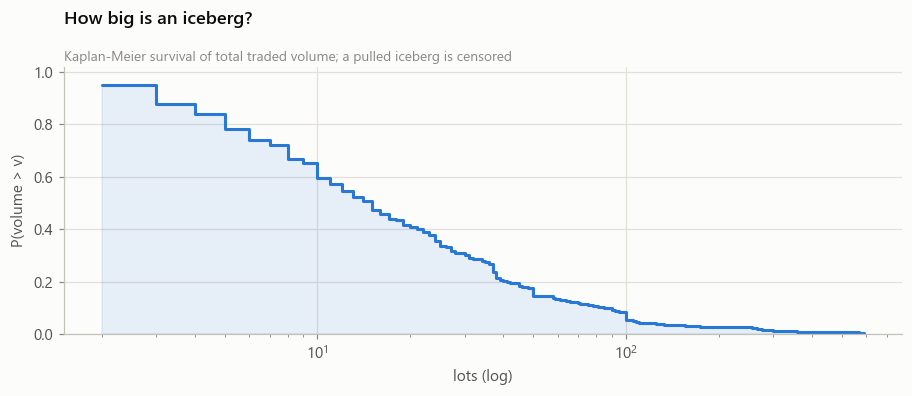

In [21]:
if len(km) > 3:
    fig, ax = plt.subplots(figsize=(8.4, 3.7))
    ax.step(km["volume"], km["survival"], where="post", color=plots.SERIES[0])
    ax.fill_between(km["volume"], km["survival"], step="post",
                    color=plots.SERIES[0], alpha=0.10)
    ax.set_xscale("log")
    ax.set_ylim(0, 1.02)
    plots._finish(ax, "How big is an iceberg?",
                  "Kaplan-Meier survival of total traded volume; a pulled iceberg is censored",
                  ylabel="P(volume > v)", xlabel="lots (log)")
    show()

The survival estimator matters because **a cancelled iceberg is a censored
observation of its own size** — what it traded is only a lower bound — so
averaging observed totals biases the distribution downward, worst in the tail,
which is the part a hidden-liquidity estimate depends on.

## 8. Which instrument moves first

At book resolution a common grid is the wrong tool: sampling asynchronous series
onto one clock drives measured comovement toward zero as the interval shrinks.
That is the Epps effect, and it is measurable here rather than taken on trust.

In [22]:
ev = panel_events(STORE, ["ZNU6", "ZFU6"], [DAY])
a = ev[ev["symbol"] == "ZNU6"]
b = ev[ev["symbol"] == "ZFU6"]
ta, pa = a["ts_recv"].astype("int64").to_numpy(), a["mid"].to_numpy()
tb, pb = b["ts_recv"].astype("int64").to_numpy(), b["mid"].to_numpy()
print(f"ZNU6 {len(ta):,} events, ZFU6 {len(tb):,} events")
print(f"share of ZNU6 events that move the mid: {np.mean(np.diff(pa) != 0):.4%}")

ep = epps_curve(ta, pa, tb, pb, freqs=("100ms", "1s", "10s", "60s", "300s"))
print()
print(ep.round(4).to_string(index=False))

ZNU6 3,873,707 events, ZFU6 2,812,398 events
share of ZNU6 events that move the mid: 0.5026%



 freq      n  grid_corr  hy_corr  epps_gap
100ms 863980     0.2516   0.0596   -0.1920
   1s  86398     0.3978   0.0596   -0.3382
  10s   8639     0.5794   0.0596   -0.5198
  60s   1439     0.7126   0.0596   -0.6530
 300s    287     0.5907   0.0596   -0.5311


The grid estimate climbs steadily with the sampling interval — the Epps effect on
our own data. But note the Hayashi-Yoshida column: it is *lower* than every grid
estimate, which is backwards, and the reason is that HY assumes no microstructure
noise while 99.6% of book events do not move the mid at all. Subsampling in
trading time is the prescribed remedy, and the signature plot chooses the subgrid.

 subsample   corr  n_pairs  still_rising
         1 0.0596  6644657         False
        20 0.1964   334198          True
       100 0.3323    66856          True
       500 0.6576    13367          True
      2000 0.8462     3341          True
     10000 1.0641      667          True

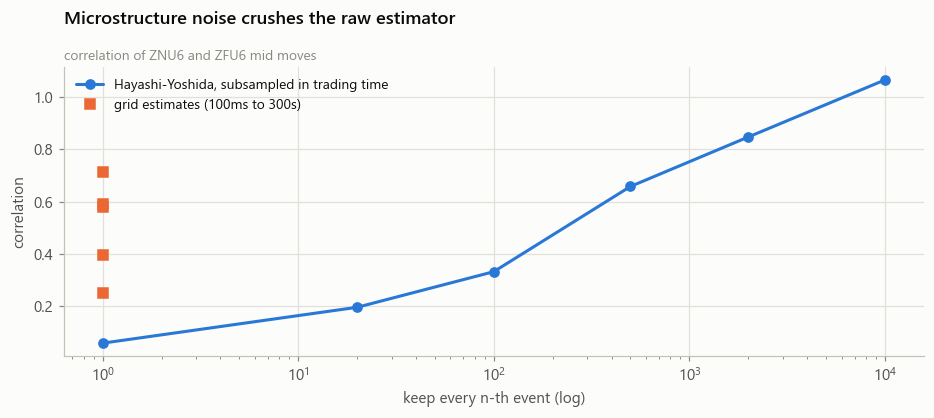

In [23]:
sig = hy_signature(ta, pa, tb, pb, factors=(1, 20, 100, 500, 2000, 10000))
print(sig.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.6, 3.9))
ax.plot(sig["subsample"], sig["corr"], marker="o", ms=6, color=plots.SERIES[0],
        label="Hayashi-Yoshida, subsampled in trading time")
ax.plot([1] * len(ep), ep["grid_corr"], ls="none", marker="s", ms=6,
        color=plots.SERIES[1], label="grid estimates (100ms to 300s)")
ax.set_xscale("log")
ax.legend(loc="upper left")
plots._finish(ax, "Microstructure noise crushes the raw estimator",
              "correlation of ZNU6 and ZFU6 mid moves",
              ylabel="correlation", xlabel="keep every n-th event (log)")
show()

## 9. Is any of this trustworthy

Three checks. The first needs no external data at all: a listed calendar and its
two outrights are three separately replayed books sharing no state — different
order ids, different price ladders — so their mids must satisfy an identity none
of them knows about.

In [24]:
iv_rows = []
for p in ("ZN", "ZF", "ZB"):
    r = implied_vs_listed(STORE, p, [DAY])
    if not r.empty:
        r["product"] = p
        iv_rows.append(r)
if iv_rows:
    ivl = pd.concat(iv_rows, ignore_index=True)
    print(ivl[["product", "symbol", "n_events_listed", "n_events_min_leg",
               "median_abs_err_ticks", "p95_abs_err_ticks"]].to_string(index=False))
    print("\nhalf a tick is the lattice floor: two books on one grid cannot agree closer")

product    symbol  n_events_listed  n_events_min_leg  median_abs_err_ticks  p95_abs_err_ticks
     ZN ZNU6-ZNZ6            17200            112401                   0.5                1.5
     ZF ZFU6-ZFZ6             4330            103862                   0.5                1.5
     ZB ZBU6-ZBZ6             1480             63568                   1.0                5.0

half a tick is the lattice floor: two books on one grid cannot agree closer


In [25]:
health = cat.assign(
    crossed_rate=cat["crossed_states"] / cat["n_tob"].replace(0, np.nan),
    outside_rate=cat["trades_outside_book"] / cat["n_trades"].replace(0, np.nan),
).groupby("product").agg(
    tob_states=("n_tob", "sum"),
    locked=("locked_states", "sum"),
    crossed=("crossed_states", "sum"),
    trades_outside=("trades_outside_book", "sum"),
)
health["crossed_per_million"] = (health["crossed"] / health["tob_states"] * 1e6).round(2)
print("replay invariants across the whole store:")
print(health.to_string())
print(f"\nvintage labels (the seam at 2026-07-07):")
print(pd.crosstab(cat["product"], cat["normalization"]).to_string())

replay invariants across the whole store:
         tob_states  locked  crossed  trades_outside  crossed_per_million
product                                                                  
SR3      2415335517     968      854            3335                 0.35
TN         92680860     441      484            2288                 5.22
UB         70456840     349      470            1604                 6.67
ZB         72063838     465      661            1555                 9.17
ZF        129830288     184     1322            4187                10.18
ZN        170610208    1074     1387            2887                 8.13
ZT        133905862     244     1081            3390                 8.07

vintage labels (the seam at 2026-07-07):
normalization   new   old  unknown
product                           
SR3            9121  7301    13783
TN              304     1      245
UB              313     0      169
ZB              368     0      117
ZF              360     0      222
ZN   

Crossed books run at a couple per million states, and trades printing outside the
prevailing quote stay at the order of a few basis points of trades — the signature
of implied matching, where a spread order executes against the outright book at a
price that book never displayed.

The vintage column is there because the archives straddle a vendor normalization
change on 2026-07-07, and SR3's June sessions carry the *newer* convention than its
July ones. Book states are identical across it; event **counts** are not.

---

### What this notebook did not cover

`pricediscovery` (Hasbrouck information share and Gonzalo-Granger component
share) needs two cointegrated series of one underlying on a common clock — a
listed spread against its legs is the natural application, and it deserves its own
study rather than a cameo here. The store also carries a `risk` partition mapping
a Treasury contract to its CTD DV01, which is what turns any of the price-unit
numbers above into yield basis points.

In [26]:
print("modules exercised:")
for m in ("products", "symbols", "archive", "book", "lifecycle", "mlofi",
          "store.reader", "store.panel", "analytics.liquidity", "analytics.flow",
          "analytics.impact", "analytics.icebergs", "analytics.leadlag",
          "analytics.mlofi", "sim", "verify", "plots"):
    print(f"  RVUtils.MBO.{m}")

modules exercised:
  RVUtils.MBO.products
  RVUtils.MBO.symbols
  RVUtils.MBO.archive
  RVUtils.MBO.book
  RVUtils.MBO.lifecycle
  RVUtils.MBO.mlofi
  RVUtils.MBO.store.reader
  RVUtils.MBO.store.panel
  RVUtils.MBO.analytics.liquidity
  RVUtils.MBO.analytics.flow
  RVUtils.MBO.analytics.impact
  RVUtils.MBO.analytics.icebergs
  RVUtils.MBO.analytics.leadlag
  RVUtils.MBO.analytics.mlofi
  RVUtils.MBO.sim
  RVUtils.MBO.verify
  RVUtils.MBO.plots
